In [1]:
!pip install tensorflow


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [4]:
print(df.head())
print(df.info())
print(df.describe())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age               

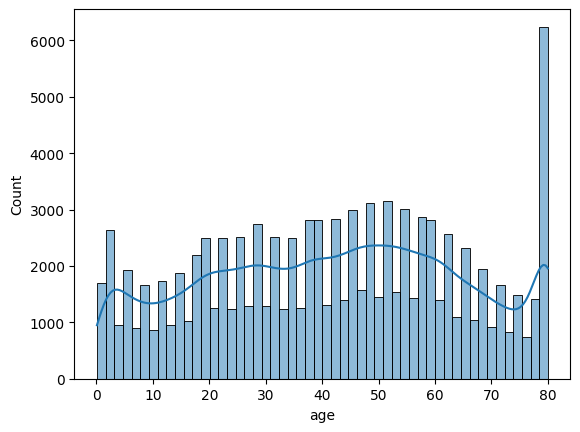

In [5]:
sns.histplot(df['age'], kde=True)
plt.show()

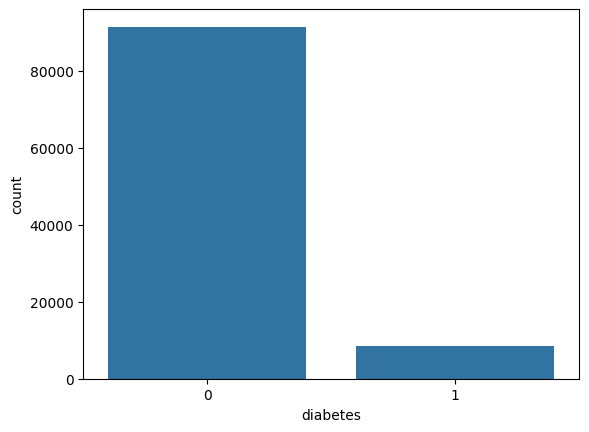

In [6]:
sns.countplot(x='diabetes', data=df)
plt.show()

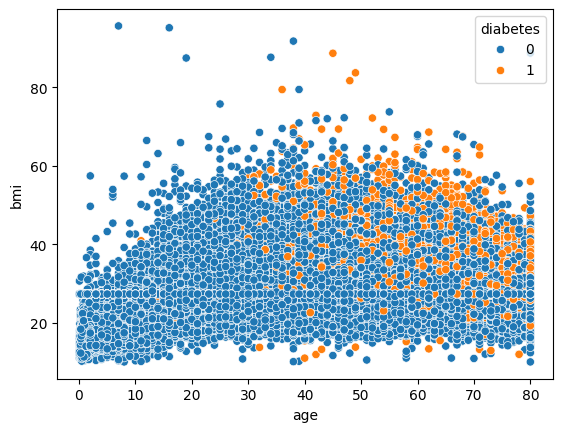

In [7]:
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df)
plt.show()

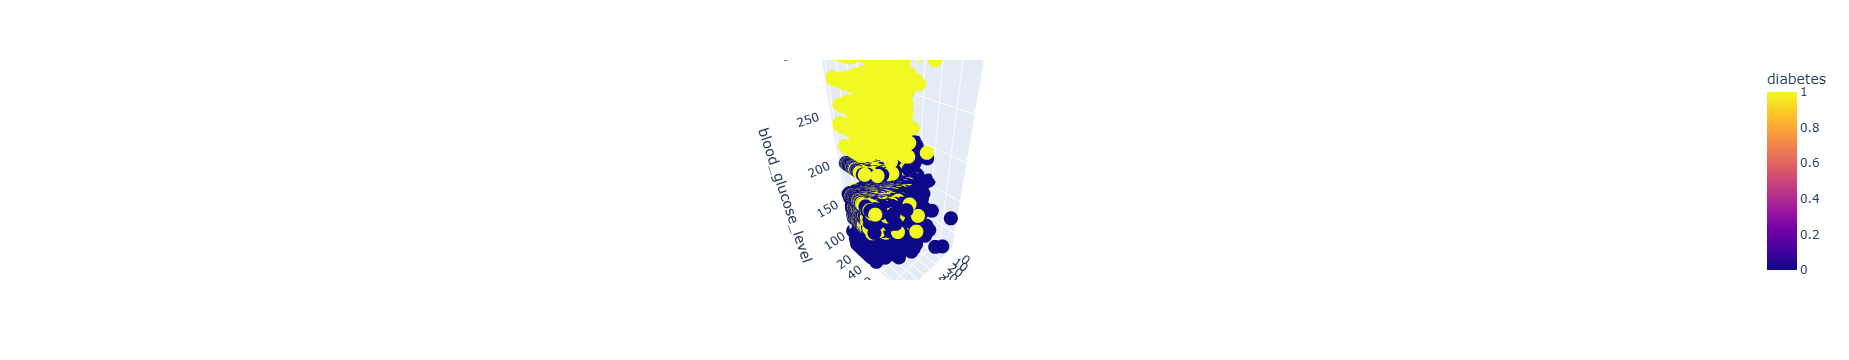

In [10]:
fig = px.scatter_3d(df, x='age', y='bmi', z='blood_glucose_level', color='diabetes')
fig.show()

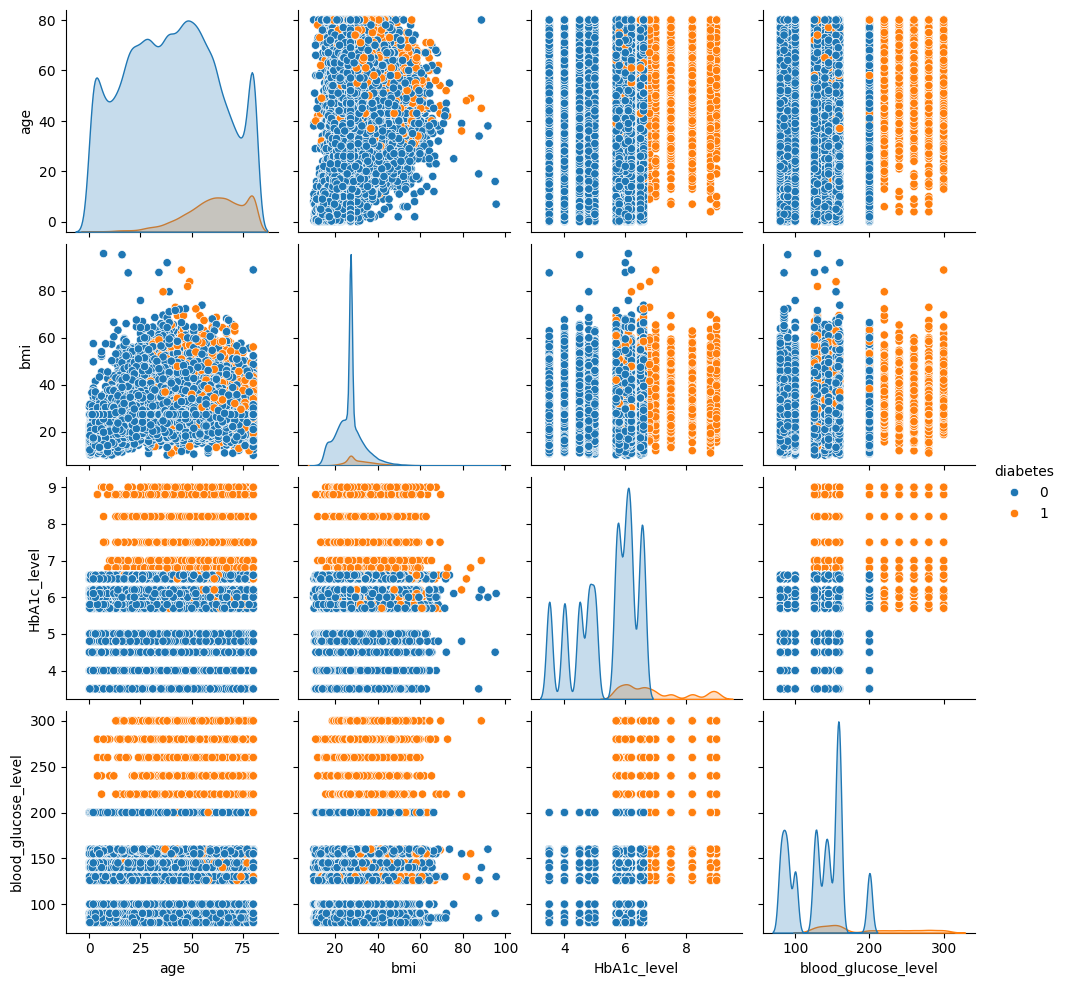

In [11]:
pair_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
sns.pairplot(df[pair_cols + ['diabetes']], hue='diabetes')
plt.show()

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']


In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9528 - loss: 0.1352 - val_accuracy: 0.9616 - val_loss: 0.1070
Epoch 2/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9626 - loss: 0.1086 - val_accuracy: 0.9673 - val_loss: 0.0979
Epoch 3/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9655 - loss: 0.0991 - val_accuracy: 0.9687 - val_loss: 0.0901
Epoch 4/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9676 - loss: 0.0937 - val_accuracy: 0.9681 - val_loss: 0.0908
Epoch 5/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9681 - loss: 0.0910 - val_accuracy: 0.9699 - val_loss: 0.0879
Epoch 6/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9690 - loss: 0.0896 - val_accuracy: 0.9700 - val_loss: 0.0870
Epoch 7/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9695 - loss: 0.0879 - val_accuracy: 0.9699 - val_loss: 0.0872
Epoch 8/25
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9694 - loss: 0.0884

In [19]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


In [20]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.97175


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       1.00      0.67      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.98      0.83      0.89     20000
weighted avg       0.97      0.97      0.97     20000



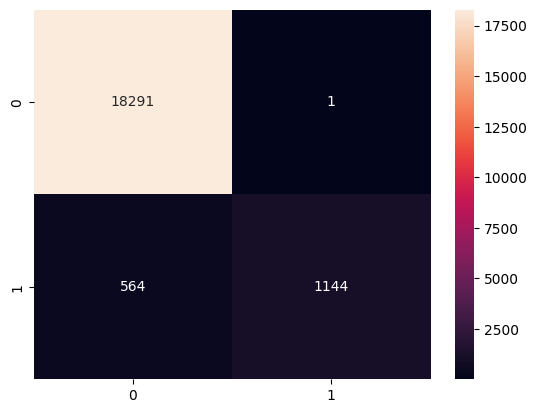

In [22]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

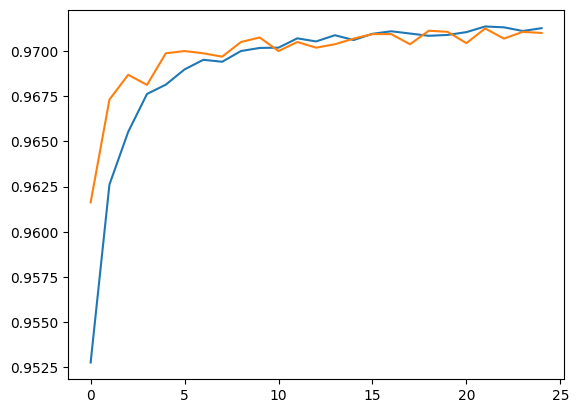

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

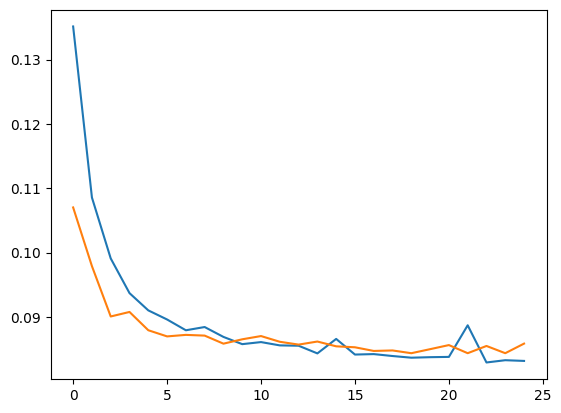

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()
